# 01 — Data Collection

## Dependencies
- Requires: StatsBomb open data locally available or `statsbombpy` installed
- Produces: `../data/events.pkl`
- Runtime: ~10 mins

# Library Imports 

In [64]:
import pandas as pd
import numpy as np
import json
import os
import glob
from pathlib import Path
from statsbombpy import sb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
warnings.filterwarnings('ignore')

In [68]:
# Portable project paths for GitHub/reproducibility.
# If this notebook is inside dl-win-probability/notebooks, PROJECT_ROOT is the repo root.
# If this notebook is run from the parent dl_project folder, it uses the clean repo folder below.
NOTEBOOK_CWD = Path.cwd().resolve()
if (NOTEBOOK_CWD / "data" / "raw").exists():
    PROJECT_ROOT = NOTEBOOK_CWD
elif (NOTEBOOK_CWD.parent / "data" / "raw").exists():
    PROJECT_ROOT = NOTEBOOK_CWD.parent
elif (NOTEBOOK_CWD / "dl-win-probability" / "data" / "raw").exists():
    PROJECT_ROOT = NOTEBOOK_CWD / "dl-win-probability"
else:
    PROJECT_ROOT = NOTEBOOK_CWD

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

COMPETITIONS_PATH = RAW_DATA_DIR / "competitions.json"
MATCHES_DIR = RAW_DATA_DIR / "matches" / "11"
EVENTS_DIR = RAW_DATA_DIR / "events"
ELO_PATH = RAW_DATA_DIR / "EloRatings.csv"

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)

Project root: C:\Users\aqeel\Downloadst\dl_project\dl-win-probability
Raw data directory: C:\Users\aqeel\Downloadst\dl_project\dl-win-probability\data\raw


# Data Collection

## Dataset 1- StatsBomb Dataset

In [72]:
#competitions
competitions = sb.competitions()

#matches
matches = sb.matches(competition_id=43, season_id=3)

#Choosing any random match
match_id = matches.iloc[0].match_id

#Events from that match
sb_df = sb.events(match_id=match_id)

In [9]:
#Printing all column names
print(sb_df.columns.tolist())
#Number of columns
print("Number of columns:", sb_df.shape[1])

['50_50', 'bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_penalty', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location', 'match_id', 'minute', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_backheel', 'pass_body_part', 'pass_cross', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_length', 'pass_outcome', 'pass_recipient', 'pass_recipient_id', 'pass_shot_assist', 'pass_switch', 'pass_type', 'period', 'play_pattern', 'player', 'player_id', 'positi

In [10]:
#Dataset example
sb_df.tail(5)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
4014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tactical,103.0,Marcus Rashford,3318.0,NaN,England,768,00:07:33.493,Substitution,NaN
4015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tactical,103.0,Cristian Eduardo Zapata Valencia,6360.0,NaN,Colombia,769,00:10:17.880,Substitution,NaN
4016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Colombia,769,00:16:06.374,Tactical Shift,NaN
4017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Colombia,769,00:31:38.320,Camera off,NaN
4018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:41:49.320,Camera off,NaN


In [11]:
#Number of seperate competitions
num_competitions = competitions.shape[0]
print("Number of competitions:", num_competitions)

#Number of Seasons
num_seasons = competitions['season_id'].nunique()
print("Number of seasons:", num_seasons)

Number of competitions: 75
Number of seasons: 48


### We will only consider la liga seasons to make the dataset smaller and easier to handle

### Load match info dataset

In [14]:
all_matches = []

for file_path in MATCHES_DIR.glob("*.json"):
    with file_path.open("r", encoding="utf-8") as f:
        data = json.load(f)
        if isinstance(data, list) and len(data) > 0:
            for match in data:
                match_flat = {
                    'match_id': match['match_id'],
                    'match_date': match['match_date'],
                    'home_team_name': match['home_team']['home_team_name'],
                    'away_team_name': match['away_team']['away_team_name'],
                    'competition_name': match['competition']['competition_name'],
                    'season_name': match['season']['season_name'],
                    'home_score': match.get('home_score'),
                    'away_score': match.get('away_score')
                }
                all_matches.append(match_flat)
        else:
            print(f"Empty or unexpected JSON: {file_path}")

matches_df = pd.DataFrame(all_matches)


### Now, we load per match event data

In [16]:
all_events = []

# Iterate over matches with both id/date and official final score.
for _, row in matches_df.iterrows():
    match_id = row['match_id']
    match_date = row['match_date']
    home_team = row['home_team_name']
    away_team = row['away_team_name']
    official_home_score = row['home_score']
    official_away_score = row['away_score']

    event_file = EVENTS_DIR / f"{match_id}.json"

    if not event_file.exists():
        print(f"Missing events file for match {match_id}")
        continue

    with event_file.open("r", encoding="utf-8") as f:
        events = json.load(f)
        if not events:
            continue
        df = pd.json_normalize(events)
        df['match_id'] = match_id
        df['match_date'] = match_date
        df['home_team'] = home_team
        df['away_team'] = away_team
        df['official_home_score'] = official_home_score
        df['official_away_score'] = official_away_score
        all_events.append(df)

if all_events:
    la_liga_events_df = pd.concat(all_events, ignore_index=True)
    print("Total La Liga events:", len(la_liga_events_df))
    print("Columns:", la_liga_events_df.columns[:10])
else:
    print("No events found at all")


Total La Liga events: 3136483
Columns: Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'type.id', 'type.name'],
      dtype='object')


### EDA

In [18]:
print("Total La Liga matches:", len(matches_df))
print(matches_df.head())

Total La Liga matches: 868
   match_id  match_date          home_team_name away_team_name  \
0      9880  2018-04-14               Barcelona       Valencia   
1      9912  2018-04-29  RC Deportivo La Coruña      Barcelona   
2      9924  2018-05-06               Barcelona    Real Madrid   
3      9855  2018-03-18               Barcelona  Athletic Club   
4      9827  2018-03-01              Las Palmas      Barcelona   

  competition_name season_name  home_score  away_score  
0          La Liga   2017/2018           2           1  
1          La Liga   2017/2018           2           4  
2          La Liga   2017/2018           2           2  
3          La Liga   2017/2018           2           0  
4          La Liga   2017/2018           1           1  


In [19]:
la_liga_events_df.head(5)

,id,index,period,timestamp,minute,second,possession,duration,type.id,type.name,...,shot.redirect,shot.follows_dribble,dribble.no_touch,injury_stoppage.in_chain,goalkeeper.lost_out,goalkeeper.success_out,goalkeeper.lost_in_play,half_start.late_video_start,half_end.early_video_end,goalkeeper.saved_to_post
0,2f8319f2-f34c-47fd-977b-332324d7d86c,1,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43fae5ba-b810-4f74-a16d-cd176c51664f,2,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,67ef9f5e-fa09-47a3-ba34-9db104d76596,3,1,00:00:00.000,0,0,1,0.000000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77f21766-088e-4b62-b9dd-e32c977f2c5d,4,1,00:00:00.000,0,0,1,0.000000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,884e0535-26fd-4299-b5e6-389f563e0c54,5,1,00:00:00.388,0,0,2,0.925053,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
print(list(la_liga_events_df.columns))

['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession', 'duration', 'type.id', 'type.name', 'possession_team.id', 'possession_team.name', 'play_pattern.id', 'play_pattern.name', 'team.id', 'team.name', 'tactics.formation', 'tactics.lineup', 'related_events', 'location', 'player.id', 'player.name', 'position.id', 'position.name', 'pass.recipient.id', 'pass.recipient.name', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.height.name', 'pass.end_location', 'pass.body_part.id', 'pass.body_part.name', 'pass.type.id', 'pass.type.name', 'carry.end_location', 'pass.outcome.id', 'pass.outcome.name', 'ball_receipt.outcome.id', 'ball_receipt.outcome.name', 'under_pressure', 'duel.type.id', 'duel.type.name', 'pass.aerial_won', 'foul_won.defensive', 'off_camera', 'pass.switch', 'dribble.outcome.id', 'dribble.outcome.name', 'counterpress', 'interception.outcome.id', 'interception.outcome.name', 'out', 'clearance.aerial_won', 'clearance.head', 'clearance.body_part.id', 'clearanc

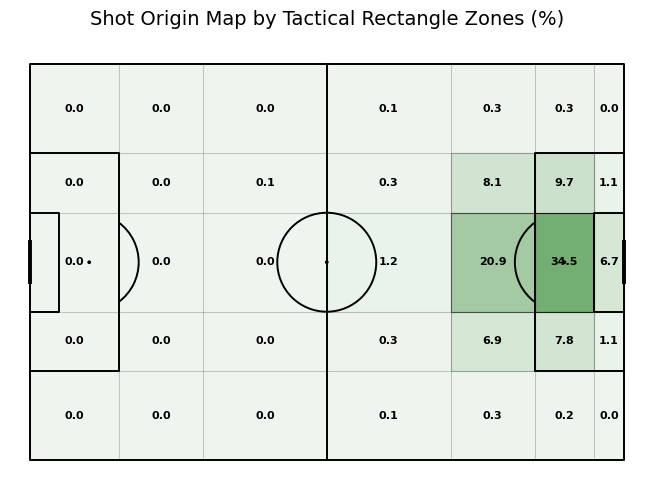

In [21]:
shots_df = la_liga_events_df[la_liga_events_df['type.name'] == 'Shot'].copy()
shots_df = shots_df.dropna(subset=['location'])

shots_df['x'] = shots_df['location'].apply(lambda loc: loc[0] if isinstance(loc, (list, tuple)) else np.nan)
shots_df['y'] = shots_df['location'].apply(lambda loc: loc[1] if isinstance(loc, (list, tuple)) else np.nan)

shots_df = shots_df.dropna(subset=['x', 'y'])

x_edges = np.array([0,18,35,60,85,102,114,120])
y_edges = np.array([0,18,30,50,62,80])

shots_df['x_bin'] = pd.cut(shots_df['x'], bins=x_edges, labels=False, include_lowest=True)
shots_df['y_bin'] = pd.cut(shots_df['y'], bins=y_edges, labels=False, include_lowest=True)

x_bin_range = np.arange(len(x_edges)-1)
y_bin_range = np.arange(len(y_edges)-1)

grid_shots = (
    shots_df.groupby(['y_bin','x_bin'])
    .size()
    .reindex(
        pd.MultiIndex.from_product(
            [y_bin_range,x_bin_range],
            names=['y_bin','x_bin']
        ),
        fill_value=0
    )
    .unstack(level=1)
)

shot_percent_grid = (grid_shots / grid_shots.values.sum()) * 100

from mplsoccer import Pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=1.4,
    line_zorder=5
)

fig, ax = pitch.draw(figsize=(8,5))

max_val = shot_percent_grid.values.max()

for yi in range(len(y_edges)-1):
    for xi in range(len(x_edges)-1):

        val = shot_percent_grid.iloc[yi, xi]

        x0 = x_edges[xi]
        x1 = x_edges[xi+1]
        y0 = y_edges[yi]
        y1 = y_edges[yi+1]

        alpha = 0.10 + (0.75 * (val / max_val)) if max_val > 0 else 0.1

        rect = plt.Rectangle(
            (x0,y0),
            x1-x0,
            y1-y0,
            facecolor='#5aa05a',
            edgecolor='black',
            linewidth=0.8,
            alpha=alpha,
            zorder=1
        )

        ax.add_patch(rect)

        ax.text(
            (x0+x1)/2,
            (y0+y1)/2,
            f"{val:.1f}",
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color='black',
            zorder=6
        )

plt.title('Shot Origin Map by Tactical Rectangle Zones (%)', fontsize=14, pad=14)
plt.tight_layout()
plt.show()

## Dataset 2- Elo ratings

In [23]:
# Loading Elo ratings CSV from repo-local raw data.
elo_df = pd.read_csv(ELO_PATH, encoding="latin1")
elo_df.head()

,date_of_elo,club,country,elo
0,7/1/2000,Aachen,GER,1453.60
1,7/1/2000,Aalborg,DEN,1482.61
2,7/1/2000,Aalst,BEL,1337.53
3,7/1/2000,Aarhus,DEN,1381.46
4,7/1/2000,Aberdeen,SCO,1360.43


In [24]:
# Filter Elo ratings to teams that appear in the loaded match metadata.
# This avoids fragile hardcoded team-name lists and handles accents consistently.
la_liga_teams = sorted(
    set(matches_df["home_team_name"].dropna()) |
    set(matches_df["away_team_name"].dropna())
)

elo_df_filtered = elo_df[elo_df["club"].isin(la_liga_teams)].copy()

missing_elo_teams = sorted(set(la_liga_teams) - set(elo_df_filtered["club"].unique()))
print("Teams in matches:", len(la_liga_teams))
print("Teams matched in Elo:", elo_df_filtered["club"].nunique())
print("Teams missing from Elo:", missing_elo_teams)

# Save generated/intermediate data under data/processed, not the repo root.
elo_df_filtered.to_csv(PROCESSED_DATA_DIR / "eloratings_laliga.csv", index=False)

elo_df_filtered.head()


Teams in matches: 41
Teams matched in Elo: 41
Teams missing from Elo: []


,date_of_elo,club,country,elo
12,7/1/2000,Deportivo Alavés,ESP,1773.22
13,7/1/2000,Albacete,ESP,1578.79
30,7/1/2000,Athletic Club,ESP,1778.66
31,7/1/2000,Atlético Madrid,ESP,1713.55
38,7/1/2000,Barcelona,ESP,1887.37


### EDA

In [26]:
# Top duplicate / frequent names
elo_df_filtered["club"].value_counts().head(20)

club
Real Madrid        599
Espanyol           599
Sevilla            599
Valencia           599
Real Valladolid    599
Osasuna            599
Levante UD         599
Villarreal         599
Sporting Gijón     599
Real Sociedad      599
Real Zaragoza      599
Celta Vigo         599
Real Betis         599
Barcelona          599
Atlético Madrid    599
Athletic Club      599
Elche              576
Getafe             576
Mallorca           576
Málaga             575
Name: count, dtype: int64

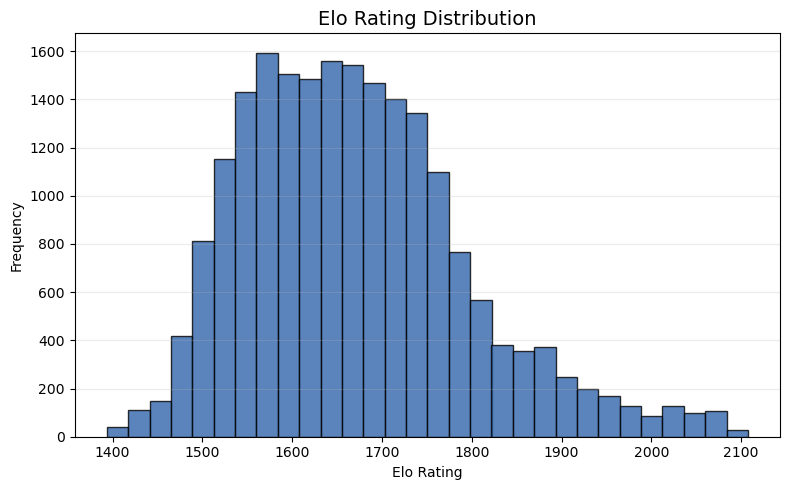

In [27]:
# Elo distribution
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    elo_df_filtered["elo"],
    bins=30,
    color="#3266ad",
    edgecolor="black",
    alpha=0.8
)

ax.set_title("Elo Rating Distribution", fontsize=14)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

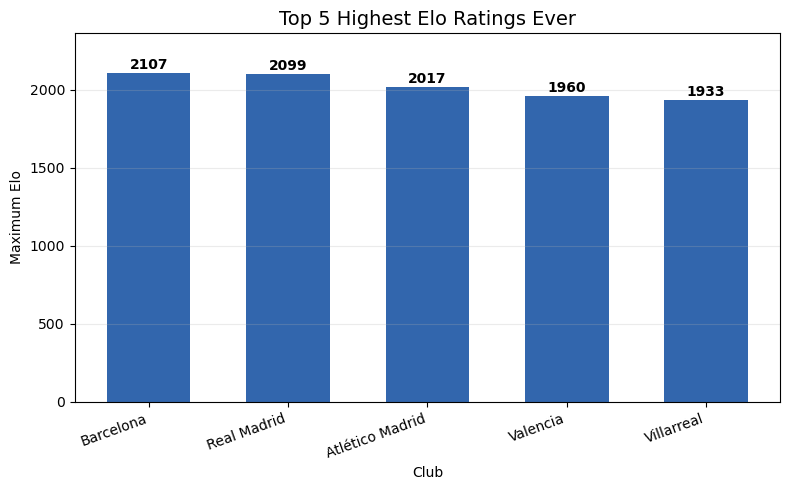

In [28]:
top5_elo = (
    elo_df_filtered.groupby("club")["elo"]
    .max()
    .sort_values(ascending=False)
    .head(5)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    top5_elo.index,
    top5_elo.values,
    color="#3266ad",
    width=0.6
)

for bar, val in zip(bars, top5_elo.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Top 5 Highest Elo Ratings Ever", fontsize=14)
ax.set_ylabel("Maximum Elo")
ax.set_xlabel("Club")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, top5_elo.max()*1.12)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Merge StatsBomb event data with Elo ratings

In [30]:
la_liga_events_df['match_date'] = pd.to_datetime(la_liga_events_df['match_date'])
elo_df_filtered = elo_df_filtered.copy()
elo_df_filtered['date_of_elo'] = pd.to_datetime(elo_df_filtered['date_of_elo'])


In [31]:
# Sort by team and date to prepare for merge_asof
elo_df_filtered_sort = elo_df_filtered.sort_values(['club', 'date_of_elo'])
la_liga_events_df_sort = la_liga_events_df.sort_values('match_date')

In [33]:
# Make sure indexes are default integers
la_liga_events_df_sort = la_liga_events_df_sort.reset_index(drop=True)

# Merge for home team
la_liga_events_df_sort = pd.merge_asof(
    la_liga_events_df_sort.sort_values('match_date'),
    elo_df_filtered_sort.rename(columns={'club': 'home_team', 'elo': 'home_elo'}).sort_values('date_of_elo'),
    left_on='match_date',
    right_on='date_of_elo',
    by='home_team',
    direction='backward'
)
la_liga_events_df_sort = la_liga_events_df_sort.drop(columns=['date_of_elo'])

# Merge for away team
la_liga_events_df_sort = pd.merge_asof(
    la_liga_events_df_sort.sort_values('match_date'),
    elo_df_filtered_sort.rename(columns={'club': 'away_team', 'elo': 'away_elo'}).sort_values('date_of_elo'),
    left_on='match_date',
    right_on='date_of_elo',
    by='away_team',
    direction='backward'
)
la_liga_events_df_sort = la_liga_events_df_sort.drop(columns=['date_of_elo'])


In [35]:
print(la_liga_events_df_sort[['home_team', 'away_team', 'match_date', 'home_elo', 'away_elo']].tail())

         home_team   away_team match_date  home_elo  away_elo
3136478  Barcelona  Celta Vigo 2021-05-16   1923.74   1716.32
3136479  Barcelona  Celta Vigo 2021-05-16   1923.74   1716.32
3136480  Barcelona  Celta Vigo 2021-05-16   1923.74   1716.32
3136481  Barcelona  Celta Vigo 2021-05-16   1923.74   1716.32
3136482  Barcelona  Celta Vigo 2021-05-16   1923.74   1716.32


In [37]:
print(la_liga_events_df_sort.columns.tolist())
print("Number of columns:",la_liga_events_df_sort.shape[1])

['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession', 'duration', 'type.id', 'type.name', 'possession_team.id', 'possession_team.name', 'play_pattern.id', 'play_pattern.name', 'team.id', 'team.name', 'tactics.formation', 'tactics.lineup', 'related_events', 'location', 'player.id', 'player.name', 'position.id', 'position.name', 'pass.recipient.id', 'pass.recipient.name', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.height.name', 'pass.end_location', 'pass.body_part.id', 'pass.body_part.name', 'pass.type.id', 'pass.type.name', 'carry.end_location', 'pass.outcome.id', 'pass.outcome.name', 'ball_receipt.outcome.id', 'ball_receipt.outcome.name', 'under_pressure', 'duel.type.id', 'duel.type.name', 'pass.aerial_won', 'foul_won.defensive', 'off_camera', 'pass.switch', 'dribble.outcome.id', 'dribble.outcome.name', 'counterpress', 'interception.outcome.id', 'interception.outcome.name', 'out', 'clearance.aerial_won', 'clearance.head', 'clearance.body_part.id', 'clearanc

In [39]:
la_liga_events_df_sort.to_pickle('../data/events.pkl')